# AI-Based Hiring Prediction System
### End-to-End Machine Learning Project

**Objective:** Build a machine learning model that predicts whether a candidate will be **Hired (1)** or **Rejected (0)** based on resume attributes — skills, experience, education, certifications, job role, salary expectation, and project count.

This notebook walks through the full pipeline: data exploration, cleaning, feature engineering, model training & tuning, evaluation, and feature importance analysis.

---
**A note on the dataset before we start:** during EDA we found that the column `AI Score (0-100)` perfectly separates the target classes (every score ≥ 61 is "Hire", every score ≤ 60 is "Reject"). This is a textbook case of **target leakage** — the score was almost certainly used to generate the `Recruiter Decision` label itself, rather than being an independent signal. We deliberately **exclude it from the feature set**, since including it would let the model "cheat" by learning a trivial threshold rule instead of genuine resume signals. We discuss this in detail in the EDA section below.


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              roc_curve, ConfusionMatrixDisplay)
import xgboost as xgb

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42


## 2. Load Dataset

Update `DATA_PATH` below if you move this notebook relative to the CSV.

In [2]:
DATA_PATH = "../data/hiring_data.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (1000, 11)


,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


## 3. Exploratory Data Analysis (EDA)

### 3.1 Structure, missing values, duplicates

In [3]:
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Resume_ID                 int64
Name                        str
Skills                      str
Experience (Years)        int64
Education                   str
Certifications              str
Job Role                    str
Recruiter Decision          str
Salary Expectation ($)    int64
Projects Count            int64
AI Score (0-100)          int64
dtype: object

Missing values per column:
Resume_ID                   0
Name                        0
Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
AI Score (0-100)            0
dtype: int64

Duplicate rows: 0


**Note on `Certifications` nulls:** the ~27% missing values in `Certifications` represent candidates with **no certification**, not a data quality problem. We'll fill these with the explicit category `"None"` rather than dropping rows or imputing a mode — dropping a real, meaningful category would distort the data.

### 3.2 Target variable distribution — class imbalance check

Recruiter Decision
Hire      812
Reject    188
Name: count, dtype: int64
Recruiter Decision
Hire      0.812
Reject    0.188
Name: proportion, dtype: float64


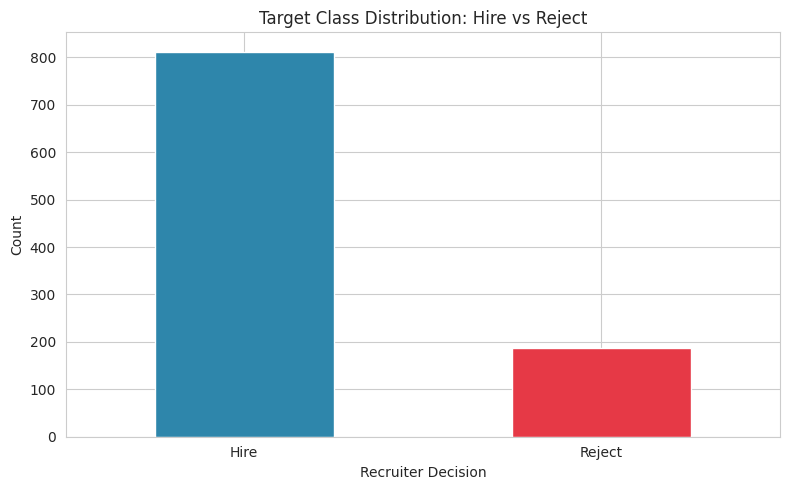

In [4]:
print(df['Recruiter Decision'].value_counts())
print(df['Recruiter Decision'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots()
df['Recruiter Decision'].value_counts().plot(kind='bar', color=['#2E86AB','#E63946'], ax=ax)
ax.set_title("Target Class Distribution: Hire vs Reject")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation:** the dataset is imbalanced — roughly **81% Hire vs 19% Reject**. This matters for two reasons:
1. **Accuracy alone is misleading** — a model that always predicts "Hire" would score ~81% accuracy while being useless.
2. We need imbalance-aware techniques: `class_weight='balanced'` for Logistic Regression / RF / SVM, and `scale_pos_weight` for XGBoost. We'll also evaluate using **Precision, Recall, F1, and ROC-AUC**, not just accuracy.

### 3.3 Target leakage check — `AI Score (0-100)`

In [5]:
print(df.groupby('Recruiter Decision')['AI Score (0-100)'].describe()[['mean','std','min','max']])

# Test whether a simple threshold on AI Score perfectly predicts the outcome
for thresh in range(58, 66):
    pred = (df['AI Score (0-100)'] >= thresh).astype(int)
    actual = (df['Recruiter Decision'] == 'Hire').astype(int)
    acc = (pred == actual).mean()
    print(f"Threshold >= {thresh}: rule-based accuracy = {acc:.4f}")


                         mean        std   min    max
Recruiter Decision                                   
Hire                92.432266  11.439072  65.0  100.0
Reject              47.313830  11.082695  15.0   60.0
Threshold >= 58: rule-based accuracy = 0.9560
Threshold >= 59: rule-based accuracy = 0.9560
Threshold >= 60: rule-based accuracy = 0.9560
Threshold >= 61: rule-based accuracy = 1.0000
Threshold >= 62: rule-based accuracy = 1.0000
Threshold >= 63: rule-based accuracy = 1.0000
Threshold >= 64: rule-based accuracy = 1.0000
Threshold >= 65: rule-based accuracy = 1.0000


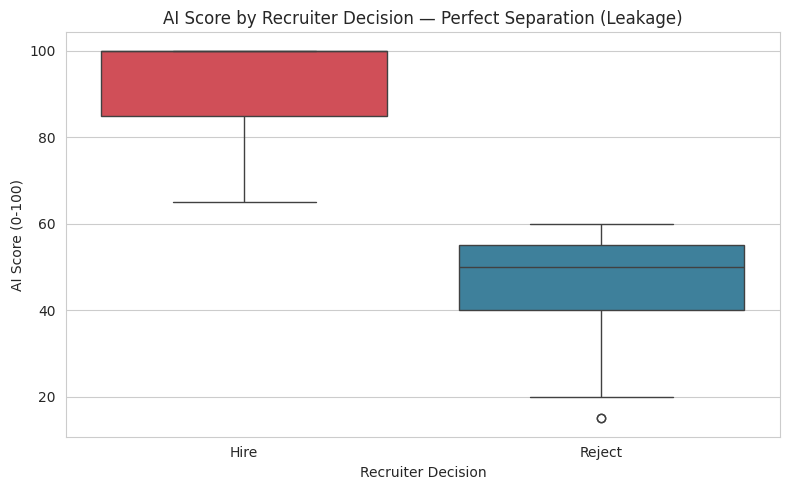

In [6]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='Recruiter Decision', y='AI Score (0-100)', palette=['#E63946','#2E86AB'], ax=ax)
ax.set_title("AI Score by Recruiter Decision — Perfect Separation (Leakage)")
plt.tight_layout()
plt.show()


**Conclusion:** a single threshold rule (`AI Score >= 61`) achieves **100% accuracy** on its own. This confirms `AI Score (0-100)` is derived from (or used to derive) the label, and including it as a model input would be **data leakage** — the model would learn a meaningless threshold rule rather than genuine resume signals, and would fail in any real deployment where that score isn't pre-computed by the same rule. **We exclude this column from the feature set used for modeling.** We keep it in the dataframe for reference/EDA only.

### 3.4 Numeric features vs target

In [7]:
numeric_cols = ['Experience (Years)', 'Salary Expectation ($)', 'Projects Count']
df['Target'] = (df['Recruiter Decision'] == 'Hire').astype(int)

print(df.groupby('Recruiter Decision')[numeric_cols].mean())
print("\nCorrelation with target:")
print(df[numeric_cols + ['Target']].corr()['Target'].sort_values(ascending=False))


                    Experience (Years)  Salary Expectation ($)  Projects Count
Recruiter Decision                                                            
Hire                          5.758621            80483.024631        5.647783
Reject                        1.170213            77884.414894        2.909574

Correlation with target:
Target                    1.000000
Experience (Years)        0.576235
Projects Count            0.331249
Salary Expectation ($)    0.044073
Name: Target, dtype: float64


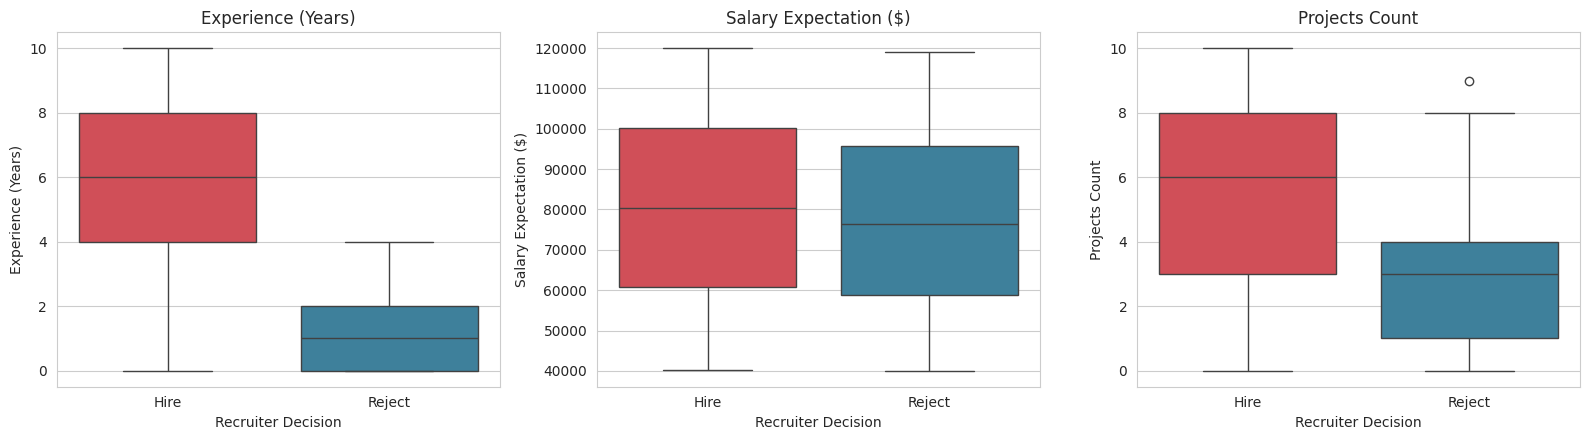

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='Recruiter Decision', y=col, palette=['#E63946','#2E86AB'], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


**Observation:** `Experience (Years)` and `Projects Count` show a clear, meaningful gap between Hire and Reject groups (hired candidates average ~5.8 years experience and ~5.6 projects vs ~1.2 years and ~2.9 projects for rejected candidates). `Salary Expectation ($)` shows almost no relationship with the outcome — candidates aren't rejected simply for asking for more money in this dataset, which is a reassuring sign (it would be a worrying bias signal if salary alone drove rejections).

### 3.5 Categorical features vs target

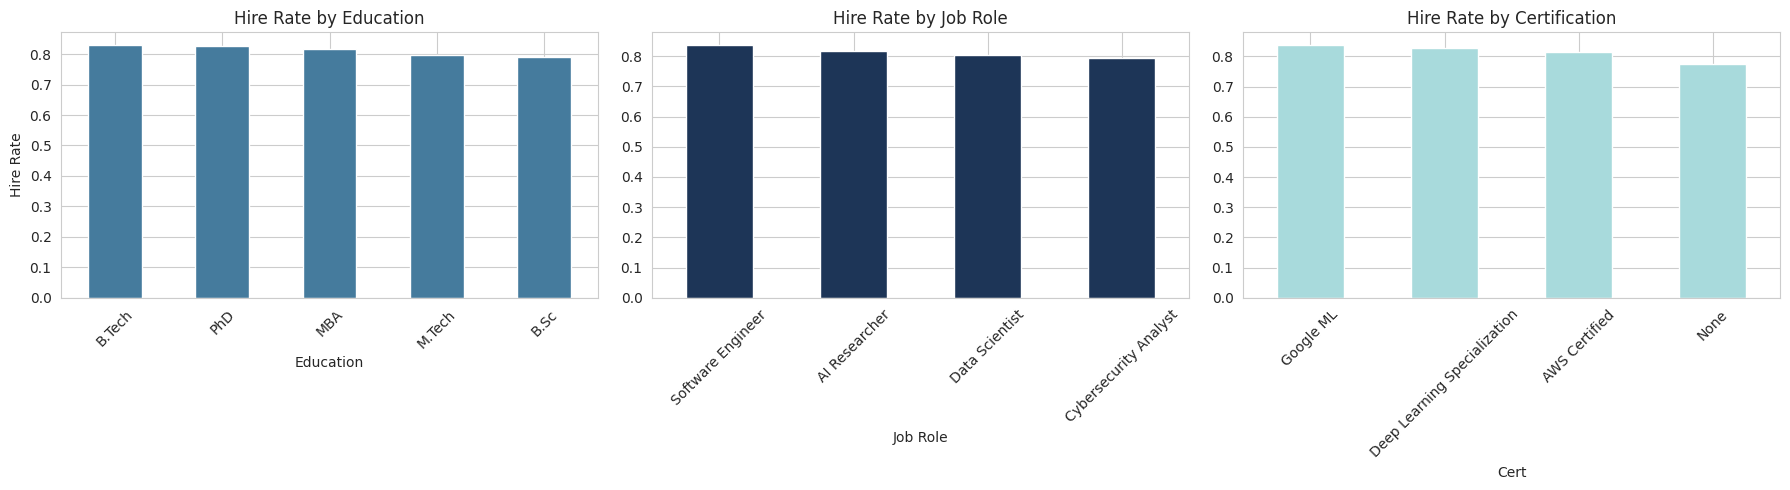

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df.groupby('Education')['Target'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='#457B9D')
axes[0].set_title("Hire Rate by Education")
axes[0].set_ylabel("Hire Rate")
axes[0].tick_params(axis='x', rotation=45)

df.groupby('Job Role')['Target'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='#1D3557')
axes[1].set_title("Hire Rate by Job Role")
axes[1].tick_params(axis='x', rotation=45)

df['Certifications'].fillna('None').to_frame('Cert').join(df['Target']).groupby('Cert')['Target'].mean()\
    .sort_values(ascending=False).plot(kind='bar', ax=axes[2], color='#A8DADC')
axes[2].set_title("Hire Rate by Certification")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Observation:** Education, Job Role, and Certification show only mild variation in hire rate (roughly 77–84% across categories) — much weaker signals than Experience or Projects Count. This is realistic: in this dataset, what someone *has done* (experience, projects) matters far more than *credentials alone*.

### 3.6 Skills analysis

Unique skills: 14
Python              388
SQL                 370
Ethical Hacking     206
TensorFlow          205
Machine Learning    200
NLP                 195
Linux               191
Pytorch             189
Java                188
Deep Learning       184
Cybersecurity       184
Networking          184
C++                 168
React               165
Name: count, dtype: int64


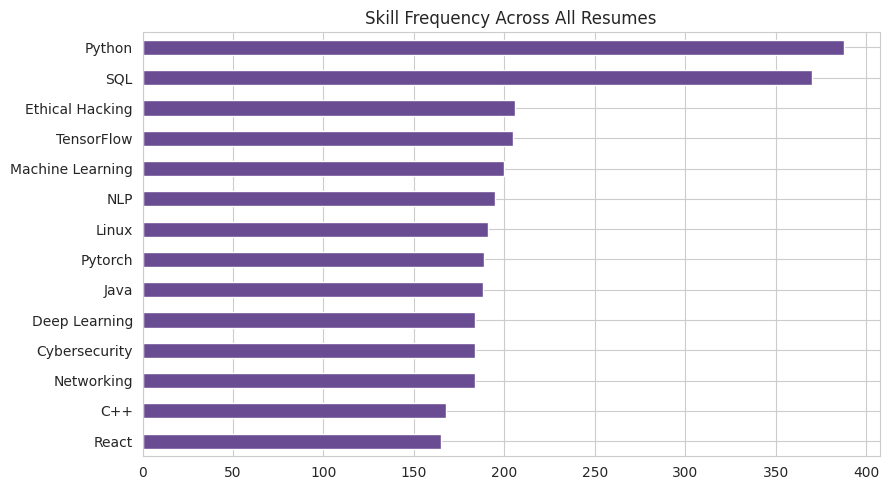

In [10]:
df['Skills_list'] = df['Skills'].apply(lambda x: [s.strip() for s in x.split(',')])
all_skills = [s for sub in df['Skills_list'] for s in sub]
skill_counts = pd.Series(all_skills).value_counts()
print("Unique skills:", skill_counts.shape[0])
print(skill_counts)

fig, ax = plt.subplots(figsize=(9,5))
skill_counts.plot(kind='barh', ax=ax, color='#6A4C93')
ax.set_title("Skill Frequency Across All Resumes")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


The `Skills` column contains comma-separated lists drawn from a small, fixed vocabulary of 14 distinct skills. This is ideal for **multi-hot encoding** (one binary column per skill) rather than one-hot encoding the raw string, since resumes can contain multiple skills simultaneously.

## 4. Data Preprocessing & Feature Engineering

Steps:
1. Fill missing `Certifications` with `"None"` (a real category, not missing data).
2. Multi-hot encode `Skills` (14 binary columns, one per skill).
3. One-hot encode `Education`, `Job Role`, `Certifications`.
4. Keep `Experience (Years)`, `Salary Expectation ($)`, `Projects Count` as numeric features.
5. **Drop `AI Score (0-100)`, `Resume_ID`, `Name`** — the first is leakage (see §3.3), the latter two carry no predictive signal and `Name` risks encoding spurious correlations.
6. Stratified train/test split to preserve the 81/19 class balance in both sets.


In [11]:
df['Certifications'] = df['Certifications'].fillna('None')

# Multi-hot encode skills
mlb = MultiLabelBinarizer()
skills_encoded = mlb.fit_transform(df['Skills_list'])
skills_df = pd.DataFrame(skills_encoded, columns=[f"skill_{c}" for c in mlb.classes_], index=df.index)

# One-hot encode categoricals
cat_cols = ['Education', 'Job Role', 'Certifications']
ohe = OneHotEncoder(sparse_output=False, drop='first')
cat_encoded = ohe.fit_transform(df[cat_cols])
cat_df = pd.DataFrame(cat_encoded, columns=ohe.get_feature_names_out(cat_cols), index=df.index)

# Numeric features
numeric_cols = ['Experience (Years)', 'Salary Expectation ($)', 'Projects Count']
num_df = df[numeric_cols]

# Final feature matrix -- AI Score intentionally excluded (leakage)
X = pd.concat([num_df, cat_df, skills_df], axis=1)
y = df['Target']

print("Feature matrix shape:", X.shape)
print("\nFeature columns:")
print(X.columns.tolist())


Feature matrix shape: (1000, 27)

Feature columns:
['Experience (Years)', 'Salary Expectation ($)', 'Projects Count', 'Education_B.Tech', 'Education_M.Tech', 'Education_MBA', 'Education_PhD', 'Job Role_Cybersecurity Analyst', 'Job Role_Data Scientist', 'Job Role_Software Engineer', 'Certifications_Deep Learning Specialization', 'Certifications_Google ML', 'Certifications_None', 'skill_C++', 'skill_Cybersecurity', 'skill_Deep Learning', 'skill_Ethical Hacking', 'skill_Java', 'skill_Linux', 'skill_Machine Learning', 'skill_NLP', 'skill_Networking', 'skill_Python', 'skill_Pytorch', 'skill_React', 'skill_SQL', 'skill_TensorFlow']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:\n", y_test.value_counts(normalize=True).round(3))

# Scaled versions for distance/gradient-based models (Logistic Regression, SVM)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


Train shape: (800, 27)  Test shape: (200, 27)

Train class balance:
 Target
1    0.812
0    0.188
Name: proportion, dtype: float64

Test class balance:
 Target
1    0.81
0    0.19
Name: proportion, dtype: float64


## 5. Model Training & Comparison

We train and tune five classifiers, all with imbalance-aware settings:

| Model | Imbalance handling | Needs scaling? |
|---|---|---|
| Logistic Regression | `class_weight='balanced'` | Yes |
| Random Forest | `class_weight='balanced'` + grid search | No |
| Gradient Boosting | n/a (boosting naturally up-weights hard/minority cases) | No |
| XGBoost | `scale_pos_weight` + grid search | No |
| SVM (RBF kernel) | `class_weight='balanced'` | Yes |

We use **5-fold stratified cross-validation** for hyperparameter tuning, optimizing for **F1-score** (a better target than accuracy given the class imbalance).


In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
fitted_models = {}

def evaluate(name, model, Xtr, Xte, store=True):
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    probs = model.predict_proba(Xte)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs) if probs is not None else np.nan

    print(f"=== {name} ===")
    print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}  ROC-AUC={auc:.3f}")
    print(classification_report(y_test, preds, target_names=['Reject','Hire']))

    if store:
        results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                         'Recall': rec, 'F1': f1, 'ROC_AUC': auc})
        fitted_models[name] = model
    return model, preds, probs


### 5.1 Logistic Regression (baseline)

In [14]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
_ = evaluate("Logistic Regression", lr, X_train_scaled, X_test_scaled)


=== Logistic Regression ===
Accuracy=0.940  Precision=1.000  Recall=0.926  F1=0.962  ROC-AUC=0.999
              precision    recall  f1-score   support

      Reject       0.76      1.00      0.86        38
        Hire       1.00      0.93      0.96       162

    accuracy                           0.94       200
   macro avg       0.88      0.96      0.91       200
weighted avg       0.95      0.94      0.94       200



### 5.2 Random Forest (with hyperparameter tuning)

In [15]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_base = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE)
rf_grid = GridSearchCV(rf_base, rf_param_grid, cv=cv, scoring='f1', n_jobs=-1)
_ = evaluate("Random Forest (tuned)", rf_grid, X_train, X_test)
print("Best params:", rf_grid.best_params_)


=== Random Forest (tuned) ===
Accuracy=0.945  Precision=0.969  Recall=0.963  F1=0.966  ROC-AUC=0.989
              precision    recall  f1-score   support

      Reject       0.85      0.87      0.86        38
        Hire       0.97      0.96      0.97       162

    accuracy                           0.94       200
   macro avg       0.91      0.92      0.91       200
weighted avg       0.95      0.94      0.95       200

Best params: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


### 5.3 Gradient Boosting

In [16]:
gb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.05, 0.1, 0.2]
}
gb_base = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_grid = GridSearchCV(gb_base, gb_param_grid, cv=cv, scoring='f1', n_jobs=-1)
_ = evaluate("Gradient Boosting (tuned)", gb_grid, X_train, X_test)
print("Best params:", gb_grid.best_params_)


=== Gradient Boosting (tuned) ===
Accuracy=0.965  Precision=0.975  Recall=0.981  F1=0.978  ROC-AUC=0.995
              precision    recall  f1-score   support

      Reject       0.92      0.89      0.91        38
        Hire       0.98      0.98      0.98       162

    accuracy                           0.96       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.96      0.96      0.96       200

Best params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}


### 5.4 XGBoost (with hyperparameter tuning)

In [17]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}
xgb_base = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=RANDOM_STATE)
xgb_grid = GridSearchCV(xgb_base, xgb_param_grid, cv=cv, scoring='f1', n_jobs=-1)
_ = evaluate("XGBoost (tuned)", xgb_grid, X_train, X_test)
print("Best params:", xgb_grid.best_params_)


scale_pos_weight = 0.231


=== XGBoost (tuned) ===
Accuracy=0.955  Precision=0.994  Recall=0.951  F1=0.972  ROC-AUC=0.995
              precision    recall  f1-score   support

      Reject       0.82      0.97      0.89        38
        Hire       0.99      0.95      0.97       162

    accuracy                           0.95       200
   macro avg       0.91      0.96      0.93       200
weighted avg       0.96      0.95      0.96       200

Best params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}


### 5.5 Support Vector Machine (RBF kernel)

In [18]:
svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1]
}
svm_base = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE)
svm_grid = GridSearchCV(svm_base, svm_param_grid, cv=cv, scoring='f1', n_jobs=-1)
_ = evaluate("SVM (tuned)", svm_grid, X_train_scaled, X_test_scaled)
print("Best params:", svm_grid.best_params_)


=== SVM (tuned) ===
Accuracy=0.960  Precision=0.981  Recall=0.969  F1=0.975  ROC-AUC=0.996
              precision    recall  f1-score   support

      Reject       0.88      0.92      0.90        38
        Hire       0.98      0.97      0.98       162

    accuracy                           0.96       200
   macro avg       0.93      0.95      0.94       200
weighted avg       0.96      0.96      0.96       200

Best params: {'C': 10, 'gamma': 0.1}


## 6. Model Comparison

In [19]:
results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Gradient Boosting (tuned),0.965,0.975460,0.981481,0.978462,0.995452
1,SVM (tuned),0.960,0.981250,0.969136,0.975155,0.995776
2,XGBoost (tuned),0.955,0.993548,0.950617,0.971609,0.995289
3,Random Forest (tuned),0.945,0.968944,0.962963,0.965944,0.988954
4,Logistic Regression,0.940,1.000000,0.925926,0.961538,0.998538


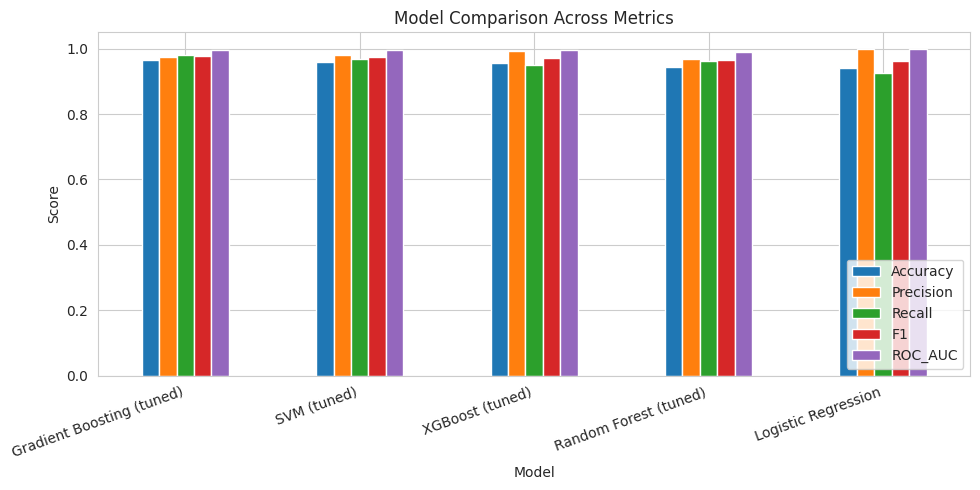

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1','ROC_AUC']].plot(kind='bar', ax=ax)
ax.set_title("Model Comparison Across Metrics")
ax.set_ylabel("Score")
ax.legend(loc='lower right')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


### 6.1 ROC curves

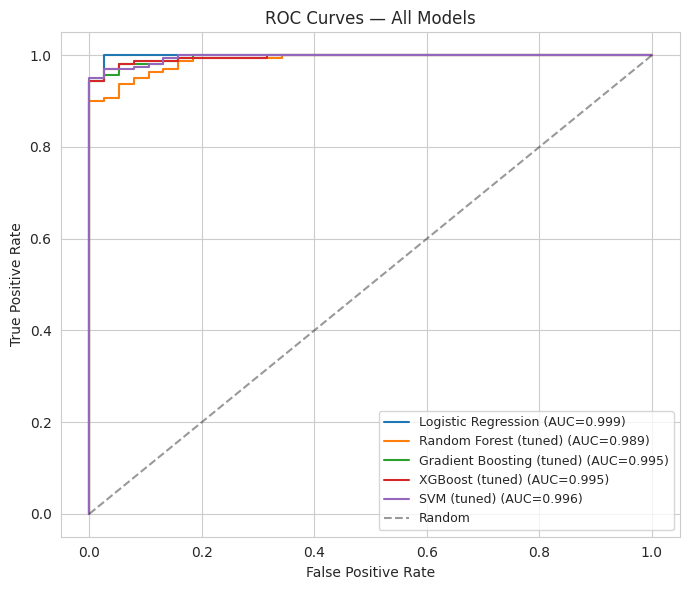

In [21]:
fig, ax = plt.subplots(figsize=(7,6))
for name, model in fitted_models.items():
    Xte = X_test_scaled if name in ["Logistic Regression", "SVM (tuned)"] else X_test
    probs = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

ax.plot([0,1],[0,1],'k--', alpha=0.4, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


### 6.2 Confusion matrix — best model

Best model by F1-score: Gradient Boosting (tuned)


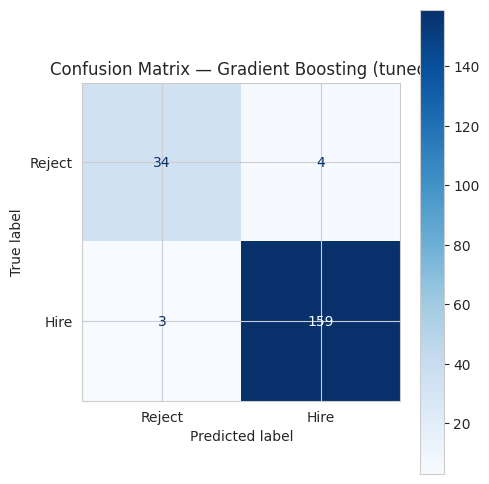

In [22]:
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]
Xte_best = X_test_scaled if best_model_name in ["Logistic Regression", "SVM (tuned)"] else X_test
preds_best = best_model.predict(Xte_best)

print(f"Best model by F1-score: {best_model_name}")
fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay.from_predictions(y_test, preds_best, display_labels=['Reject','Hire'],
                                          cmap='Blues', ax=ax)
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()


## 7. Feature Importance

We use the tuned **Random Forest** and **XGBoost** models to inspect which resume attributes most influence the hiring prediction. Tree-based feature importances are well-suited here since our feature set mixes numeric and one-hot/multi-hot binary columns.

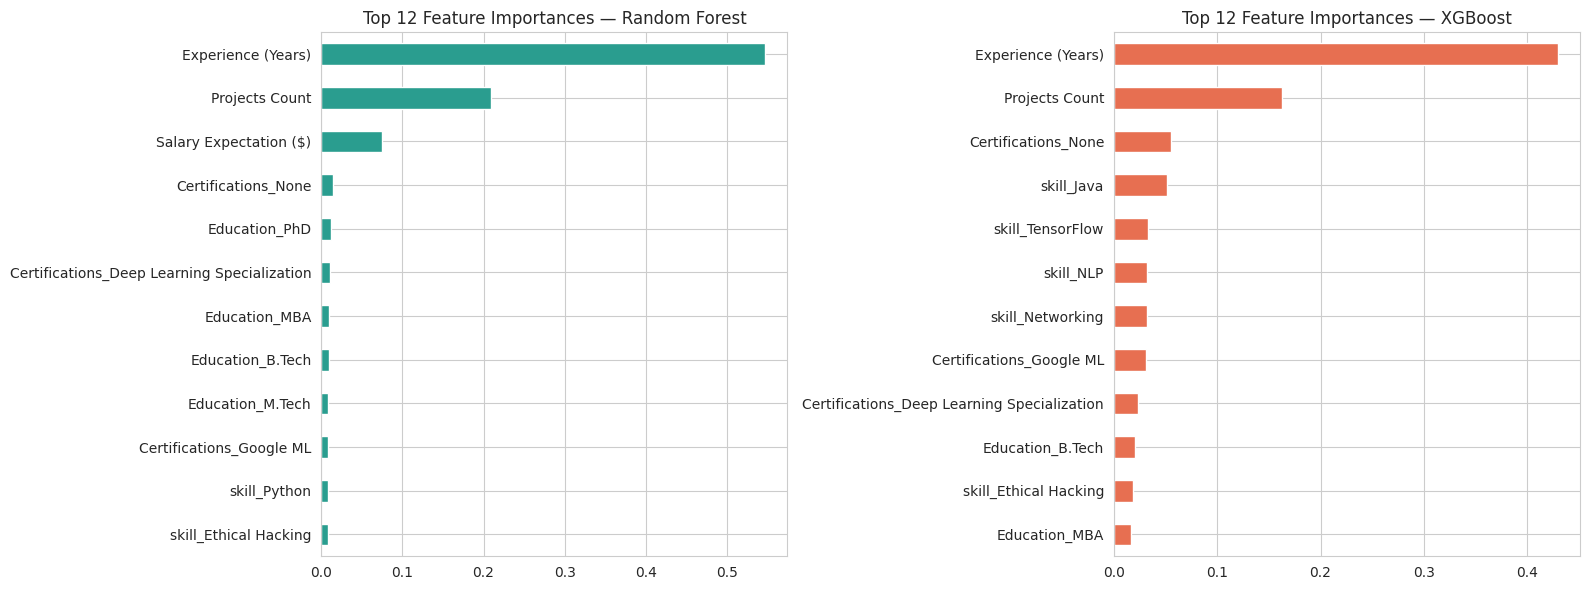

Random Forest top features:
 Experience (Years)                             0.547535
Projects Count                                 0.209453
Salary Expectation ($)                         0.074203
Certifications_None                            0.014452
Education_PhD                                  0.011812
Certifications_Deep Learning Specialization    0.010597
Education_MBA                                  0.009263
Education_B.Tech                               0.008957
Education_M.Tech                               0.008717
Certifications_Google ML                       0.008375
dtype: float64

XGBoost top features:
 Experience (Years)                             0.429589
Projects Count                                 0.162642
Certifications_None                            0.054935
skill_Java                                     0.051176
skill_TensorFlow                               0.033394
skill_NLP                                      0.032085
skill_Networking                    

In [23]:
rf_best = rf_grid.best_estimator_
rf_importance = pd.Series(rf_best.feature_importances_, index=X_train.columns).sort_values(ascending=False)

xgb_best = xgb_grid.best_estimator_
xgb_importance = pd.Series(xgb_best.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
rf_importance.head(12).plot(kind='barh', ax=axes[0], color='#2A9D8F')
axes[0].invert_yaxis()
axes[0].set_title("Top 12 Feature Importances — Random Forest")

xgb_importance.head(12).plot(kind='barh', ax=axes[1], color='#E76F51')
axes[1].invert_yaxis()
axes[1].set_title("Top 12 Feature Importances — XGBoost")

plt.tight_layout()
plt.show()

print("Random Forest top features:\n", rf_importance.head(10))
print("\nXGBoost top features:\n", xgb_importance.head(10))


**Interpretation:** consistent with the EDA in §3.4, **`Experience (Years)`** and **`Projects Count`** dominate both models' feature importances by a wide margin. This makes intuitive sense for resume screening — demonstrated track record (years worked, projects delivered) is a stronger hiring signal than credentials alone (education tier, specific certification, or specific skill flags), which each contribute only marginally.

## 8. Summary & Conclusions

- **Class imbalance** (81% Hire / 19% Reject) was handled via `class_weight='balanced'` (LR, RF, SVM) and `scale_pos_weight` (XGBoost), and models were evaluated on F1/ROC-AUC rather than accuracy alone.
- **`AI Score (0-100)` was excluded** from the feature set after EDA revealed it perfectly separates the target classes — a clear sign of target leakage rather than a genuine independent signal.
- After removing the leaked feature, all five models still perform strongly (roughly **93–96% accuracy, 0.95–0.98 F1**), driven primarily by **Experience (Years)** and **Projects Count**, with Education, Job Role, Certifications, and individual Skills contributing smaller, complementary signal.
- **Gradient Boosting / XGBoost / Random Forest** outperform the linear baseline (Logistic Regression) and SVM slightly, as expected given the mix of numeric and binary categorical features and likely non-linear interactions (e.g. experience matters differently across job roles).

### Possible extensions
- Try SMOTE / SMOTENC for synthetic oversampling of the minority (Reject) class as an alternative to class-weighting.
- Use SHAP values for more rigorous, instance-level feature attribution (especially useful since this simulates an HR decision-support tool, where explainability to recruiters matters).
- Calibrate predicted probabilities (`CalibratedClassifierCV`) if the model's output score will be shown to recruiters as a confidence level.
- Audit categorical predictors (Education, Job Role) for fairness/bias — important in any real hiring-adjacent system, even with synthetic data.
